In [1]:
# Importing torch and setting the device
import torch

# Setting GPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Properties
print(torch.cuda.get_device_name())
print(torch.cuda.get_device_capability()) # torch.cuda.get_device_properties()

NVIDIA GeForce MX350
(6, 1)


*A PyTorch computational graph is a Directed Acyclic Graph (DAG) that represents the sequence of operations performed on tensors during the forward pass of a model. This graph is dynamically built during runtime, meaning it is constructed on the fly as operations are executed.*

#### AutoGrad for Scalers

In [20]:
x = torch.tensor(3.0, requires_grad=True) # Enables the differentation wrt this variable (x)
x

tensor(3., requires_grad=True)

In [21]:
y = x**2
y

tensor(9., grad_fn=<PowBackward0>)

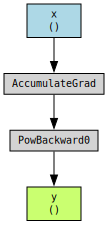

In [22]:
# Visualizing the computational graph using torchviz
from torchviz import make_dot
make_dot(var=y, params={"x": x, "y": y})

*`backward` - Computes the gradient of current tensor wrt graph leaves. The graph is differentiated using the chain rule.*

In [23]:
y.backward(retain_graph = True)
# Computational Graph: X -> square function -> y(leaf node)

In [24]:
x.grad
# Differentation wrt x

tensor(6.)

*Note: When you run `y.backward()` again (only if `retain_graph = True`) then PyTorch saves the gradient in its memory and add it when you run it again.*

In [25]:
x = torch.tensor(4.0, requires_grad=True)
y = 2 * x * (torch.cos(x) ** 2) # Multiplication Rule of Derivative
z = torch.sin(y)

In [26]:
x

tensor(4., requires_grad=True)

In [27]:
y

tensor(3.4180, grad_fn=<MulBackward0>)

In [28]:
z

tensor(-0.2729, grad_fn=<SinBackward0>)

`Computational Graph`: X    —→    func(2 * x * cos(x)) = y    —→    func(sin(y)) = z

In [29]:
z.backward()

In [30]:
x.grad
# y.grad - You only able to calculate the gradient wrt leaf node (the last variable) only

tensor(6.7924)

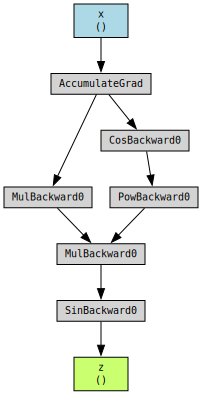

In [35]:
make_dot(var=z, params={'x': x, 'z': z})

*Gradients of non leaf node(z) will not be calculated*

---

#### Basic AutoGrad from scratch

In [36]:
# Inputs
x = torch.tensor(6.7)  # Input feature
y = torch.tensor(0.0)  # True label (binary)

w = torch.tensor(1.0)  # Weight
b = torch.tensor(0.0)  # Bias

In [37]:
# Binary Cross-Entropy Loss for scalar
def binary_cross_entropy_loss(prediction, target):
    epsilon = 1e-8  # To prevent log(0)
    prediction = torch.clamp(prediction, epsilon, 1 - epsilon)
    return -(target * torch.log(prediction) + (1 - target) * torch.log(1 - prediction))

In [38]:
# Forward pass
z = w * x + b  # Weighted sum (linear part)
y_pred = torch.sigmoid(z)  # Predicted probability

# Compute binary cross-entropy loss
loss = binary_cross_entropy_loss(y_pred, y)
loss

tensor(6.7012)

In [39]:
# Derivatives:
# 1. dL/d(y_pred): Loss with respect to the prediction (y_pred)
dloss_dy_pred = (y_pred - y)/(y_pred*(1-y_pred))

# 2. dy_pred/dz: Prediction (y_pred) with respect to z (sigmoid derivative)
dy_pred_dz = y_pred * (1 - y_pred)

# 3. dz/dw and dz/db: z with respect to w and b
dz_dw = x  # dz/dw = x
dz_db = 1  # dz/db = 1 (bias contributes directly to z)

# Chain Rule
dL_dw = dloss_dy_pred * dy_pred_dz * dz_dw
dL_db = dloss_dy_pred * dy_pred_dz * dz_db

In [40]:
print(f"Manual Gradient of loss w.r.t weight (dw): {dL_dw}")
print(f"Manual Gradient of loss w.r.t bias (db): {dL_db}")

Manual Gradient of loss w.r.t weight (dw): 6.691762447357178
Manual Gradient of loss w.r.t bias (db): 0.998770534992218


In [41]:
x = torch.tensor(6.7)
y = torch.tensor(0.0)

w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

In [42]:
# Forward Pass
z = w*x + b
z

tensor(6.7000, grad_fn=<AddBackward0>)

In [43]:
# Predict Probabilities
y_pred = torch.sigmoid(z)
y_pred

tensor(0.9988, grad_fn=<SigmoidBackward0>)

In [44]:
loss = binary_cross_entropy_loss(y_pred, y)
loss

tensor(6.7012, grad_fn=<NegBackward0>)

`Computational Graph`: w, b    —→    foreard pass(x, w, b) = z    —→    probabilities(z) = y_pred    —→    loss(y_pred, y_actual)

In [45]:
loss.backward()

In [46]:
print(w.grad)
print(b.grad)

tensor(6.6918)
tensor(0.9988)


---

#### AutoGrad for Tensors

In [47]:
# Gradients with multiple X values
x = torch.tensor([[1.0, 2.0, 3.0], [2.5, 9.8, 5.7]], requires_grad = True)
x

tensor([[1.0000, 2.0000, 3.0000],
        [2.5000, 9.8000, 5.7000]], requires_grad=True)

In [48]:
y = (x**2).mean()
y

tensor(24.7967, grad_fn=<MeanBackward0>)

In [49]:
y.backward()

In [50]:
x.grad

tensor([[0.3333, 0.6667, 1.0000],
        [0.8333, 3.2667, 1.9000]])

---

#### Gradient Accumulation

In [51]:
# clearing grad
x = torch.tensor(2.0, requires_grad = True)
x

tensor(2., requires_grad=True)

In [52]:
y = x ** 2
y

tensor(4., grad_fn=<PowBackward0>)

In [53]:
y.backward(retain_graph=True)

In [54]:
x.grad

tensor(4.)

*You will not be able to run the `y.backward()` more than one time → Throws an error unless `retain_graph=True`*

*The problem with executing `y.backward()` and `x.grad` muptiple times will store the gradient values in the memory → If you run this more than one time then ouptut will be `d1 + d2 + ...` - The values of gradients will get added only if `retain_graph=True`*

In [55]:
# Inplace operation
x.grad.zero_()

# Or you can use this as well
x.grad = torch.zeros_like(input=x.grad)

---

#### Disable gradient tracking

In [56]:
x = torch.tensor(2.0, requires_grad=True)
y = x ** 2

y.backward(retain_graph=True)
x.grad

tensor(4.)

In [57]:
# Way 1: requires_grad_ - perminantly disable the gradients
x.requires_grad_(False) # requires_grad = False (_ inplace)

tensor(2.)

In [58]:
y = x ** 2 # Calculating y again after updating the state of x

try:
    y.backward()
except Exception as e:
    print(e)

element 0 of tensors does not require grad and does not have a grad_fn


In [59]:
x = torch.tensor(2.0, requires_grad=True)
y = x ** 2

y.backward()
x.grad

tensor(4.)

In [60]:
# Way 2: detach() - The variable gets detached from the DAG
z = x.detach() # Copy the value of x but its requires_grad becomes false
z

tensor(2.)

In [61]:
y = z ** 2
y

tensor(4.)

In [62]:
try:
    y.backward()
except Exception as e:
    print(e)

element 0 of tensors does not require grad and does not have a grad_fn


In [63]:
# Consider you are training your neural network

x = torch.tensor([1.0, 2.0], requires_grad=True) # Only Tensors of floating point and complex dtype can require gradients

x = torch.tensor(2.4, requires_grad=True)
y = x ** 2
y.backward()
print(x.grad)
# The neural network is trained

# Its prediction time
with torch.no_grad():
    # In this scope only, all the parameter's requires_grad parameter becomes false
    y = x + 10

    try:
        y.backward()
        print(x.grad())
    except Exception as e:
        print(e)

# For an instance, need to run a block of code without building a DAG, then you can stop the gradients by using context manager

tensor(4.8000)
element 0 of tensors does not require grad and does not have a grad_fn


*`torch.no_grad()` is the most recommended way to stop calculating or tracking grad*

In large-scale applications like training and deploying **LLMs** (Large Language Models), these three methods are essential for managing memory and controlling which parts of the massive model actually learn.

Here is where each method is used in the "real world":

##### 1. `with torch.no_grad()`
**Used for: Inference and Evaluation**
*   **Generation:** When you ask an LLM to generate text (Inference), you are only doing a "forward pass." You don't need gradients to update weights. Using `no_grad()` prevents PyTorch from storing "activations" (intermediate values), which **reduces VRAM usage by ~50% or more**, allowing you to run much larger models on the same GPU.
*   **Validation Loops:** When calculating the validation loss or Perplexity during training, we wrap the code in `no_grad()` to ensure we don't accidentally update the model on the test data.

##### 2. `requires_grad_(False)`
**Used for: Freezing Layers (Fine-tuning)**
*   **LoRA / PEFT (Parameter-Efficient Fine-Tuning):** This is the most common use case today. When fine-tuning a model like Llama-3, we don't want to update all 70 billion parameters. We set `requires_grad = False` for the entire model and only enable it for tiny "adapter" layers.
*   **Freezing Embeddings:** Often, the "Embedding layer" (the dictionary that maps words to vectors) is already well-trained. Researchers often freeze it to save computation and prevent the model from forgetting basic language meanings.

##### 3. `.detach()`
**Used for: Breaking the Gradient Flow (Architectural Logic)**
*   **Contrastive Learning (e.g., CLIP):** In models that compare two different inputs (like an image and a caption), you might want to calculate the similarity but only update the "Image Encoder" and not the "Text Encoder" in a specific step. You `.detach()` the text features to "blind" the gradient flow to that branch.
*   **RLHF (Reinforcement Learning from Human Feedback):** During the PPO (Proximal Policy Optimization) phase, you often have a "Reference Model" and a "Policy Model." You use the Reference Model to ensure the Policy doesn't change too much, but you `.detach()` its outputs so you don't accidentally try to train the Reference Model itself.
*   **Logging:** When sending a loss value or a metric to a dashboard (like Weights & Biases), you must use `.detach().item()` or `.detach().cpu()`. If you don't, the entire computational graph stays in memory, leading to a **memory leak** that will eventually crash your training.

##### Summary Table for LLMs

| Method | Real-world Context | Primary Benefit |
| :--- | :--- | :--- |
| **`no_grad()`** | Chatting with the bot (Inference) | Huge Memory Savings |
| **`requires_grad_(False)`** | LoRA Fine-tuning / Freezing | Faster Training / Targeted Learning |
| **`detach()`** | CLIP, RLHF, or Logging | Control Logic / Prevent Memory Leaks |

> Additional Information <br><br>
> [Gradients for non-differentiable functions](https://docs.pytorch.org/docs/stable/notes/autograd.html#gradients-for-non-differentiable-functions)
>
> [Division by Zero in Autograd](https://docs.pytorch.org/docs/stable/notes/autograd.html#division-by-zero-in-autograd) 